run this headless

conda activate guitarmidi
screen jupyter nbconvert --to notebook --execute traning.ipynb --output=output_notebook.ipynb --ExecutePreprocessor.timeout=-1



Mixed precision policy set to 'mixed_float16'.
Memory growth enabled for GPUs.
TensorFlow version: 2.19.0


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 312, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 312, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 256, 312, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 156, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 156, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 156, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 128, 156, 64)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 78, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 78, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_5             │ (None, 64, 78, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 39, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 89)             │        11,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,049 (410.35 KB)

 Trainable params: 104,601 (408.60 KB)

 Non-trainable params: 448 (1.75 KB)

Found 49164 files on disk.

--- Training Pure CNN Model ---
Epoch 1/100
   3/2151 ━━━━━━━━━━━━━━━━━━━━ 1:03 30ms/step - accuracy: 0.0000e+00 - loss: 0.7920 

2025-07-16 20:04:02.581053: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_7', 8 bytes spill stores, 8 bytes spill loads



   8/2151 ━━━━━━━━━━━━━━━━━━━━ 1:15 35ms/step - accuracy: 0.0078 - loss: 0.7583   

KeyboardInterrupt: 

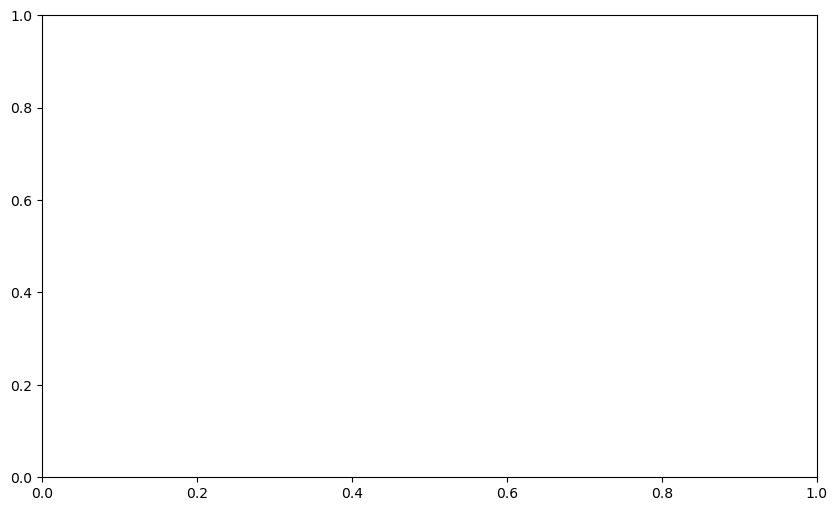

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from model import build_cnn_model
import common
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files

# --- Essential for GPU memory management ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # Corrected
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- Configuration (using values from serialization part) ---

LEARNING_RATE = 0.001
BATCH_SIZE = 16 # Adjust as needed
EPOCHS = 100

# Directories where slices were saved
input_data_dir = 'data_slices/input'
output_data_dir = 'data_slices/output'

# --- Custom Callback for Live Loss Plotting (remains the same) ---
class PlotLoss(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.val_losses = []
        self.epochs_run = []
        self.fig, self.ax = plt.subplots(figsize=(10, 6))

    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        if logs.get('val_loss') is not None:
            self.val_losses.append(logs.get('val_loss'))
        self.epochs_run.append(epoch + 1)

        clear_output(wait=True)
        self.ax.clear()
        self.ax.plot(self.epochs_run, self.losses, label='Training Loss')
        if self.val_losses:
            self.ax.plot(self.epochs_run, self.val_losses, label='Validation Loss')
        self.ax.set_xlabel('Epoch')
        self.ax.set_ylabel('Loss')
        self.ax.set_title('Training and Validation Loss Over Epochs')
        self.ax.legend()
        self.ax.grid(True)
        plt.show()

# --- 1. Define the Pure CNN Model (remains the same) ---


# --- 2. Compile the Model (remains the same) ---
cnn_model = build_cnn_model(INPUT_SHAPE, OUTPUT_DIM)
cnn_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

# --- 3. Data Loading and Preparation (Stream from Disk - .npy files) ---

# Get lists of all input and output file paths
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '*.npy')))
output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy')))

total_samples_on_disk = len(input_filepaths)
if total_samples_on_disk == 0:
    print(f"ERROR: No .npy files found in {input_data_dir}. Please run the serialization script first.")
    exit()
if total_samples_on_disk != len(output_filepaths):
    print("ERROR: Mismatch in number of input and output files.")
    exit()

print(f"Found {total_samples_on_disk} files on disk.")


# Function to load a single image and its label from file paths
def load_sample_from_files(input_path_tensor, output_path_tensor):
    # Convert TensorFlow string tensors to Python strings
    input_path = input_path_tensor.numpy().decode('utf-8')
    output_path = output_path_tensor.numpy().decode('utf-8')

    # Load the NumPy arrays
    image = np.load(input_path).astype(np.float32).reshape(INPUT_SHAPE)
    
    label = np.load(output_path).astype(np.float32).reshape(OUTPUT_DIM)

    # Ensure the image has the correct shape (H, W, C)
    image = tf.ensure_shape(image, INPUT_SHAPE)
    label = tf.ensure_shape(label, (OUTPUT_DIM,)) # Ensure label shape is correct

    return image, label


def tf_load_sample_from_files(ipath, opath):
    image, label = tf.py_function(
        load_sample_from_files, [ipath, opath], [tf.float32, tf.float32]
    )
    # Explicitly set shapes here!
    image.set_shape(INPUT_SHAPE)
    label.set_shape((OUTPUT_DIM,))
    return image, label
# Create a dataset from the lists of file paths
# These lists of paths are small enough to be held in RAM.
dataset = tf.data.Dataset.from_tensor_slices((input_filepaths, output_filepaths))

# Shuffle the list of paths first
dataset = dataset.shuffle(buffer_size=total_samples_on_disk) # Buffer size for shuffling paths

# Split the dataset into training and validation subsets based on indices
split_ratio = 0.7
num_train = int(total_samples_on_disk * split_ratio)

train_dataset = dataset.take(num_train)
val_dataset = dataset.skip(num_train)

# Map the loading function to the datasets using tf.py_function
# This function will load data from disk for each sample as it's needed
train_dataset = train_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE # Load in parallel threads/processes
)
val_dataset = val_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Apply batching and prefetching
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

plot_callback = PlotLoss()

# --- 4. Training the Model ---
print("\n--- Training Pure CNN Model ---")
try:
    history_cnn = cnn_model.fit(train_dataset,
                                epochs=EPOCHS,
                                validation_data=val_dataset,
                                callbacks=[plot_callback])
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
except Exception as e:
    print(f"An error occurred during training: {e}")